In [1]:
import requests 
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import illustris_python as il
import matplotlib.colors as colors

# Goal: Remake SFH plots from the PHAST proposal for the Roman Cycle 1 proposal but use a new set of M31 analogs

In [2]:
#function that gives path to data
def get(path, params=None):
	# make HTTP GET request to path
	headers = {"api-key":"624abff74a436f05f87b576b68b19a76"}
	r = requests.get(path, params=params, headers=headers)
	
	# raise exception if response code is not HTTP SUCCESS (200)
	r.raise_for_status()
	
	if r.headers['content-type'] == 'application/json':
	    return r.json() # parse json responses automatically
	
	if 'content-disposition' in r.headers:
	    filename = r.headers['content-disposition'].split("filename=")[1]
	    with open(filename, 'wb') as f:
	        f.write(r.content)
	    return filename # return the filename string
	
	return r

In [18]:
def save_particle_data(subhalo_id):
	params = {'stars':'Coordinates,Velocities,GFM_StellarFormationTime,Masses,GFM_Metallicity','gas':'Coordinates,Velocities,Masses,NeutralHydrogenAbundance,StarFormationRate,GFM_Metallicity','dm':'Coordinates,Velocities,Potential'} 
	url = "http://www.tng-project.org/api/TNG50-1/snapshots/z=0/subhalos/" + str(int(subhalo_id))
	saved_filename = get(url + "/cutout.hdf5",params) #hdf5 file with all the data
	f = h5py.File(saved_filename, 'r') #read the file in order to save the data
	# stars = f['PartType4']
	# gas = f['PartType0']
	# dm = f['PartType1']
	star_x = f['PartType4']['Coordinates'][:,0]
	star_y = f['PartType4']['Coordinates'][:,1]
	star_z = f['PartType4']['Coordinates'][:,2]
	star_vx = f['PartType4']['Velocities'][:,0]
	star_vy = f['PartType4']['Velocities'][:,1]
	star_vz = f['PartType4']['Velocities'][:,2]
	star_mass = f['PartType4']['Masses']
	star_tform = f['PartType4']['GFM_StellarFormationTime']
	star_met = f['PartType4']['GFM_Metallicity']
	
	gas_x = f['PartType0']['Coordinates'][:,0]
	gas_y = f['PartType0']['Coordinates'][:,1]
	gas_z = f['PartType0']['Coordinates'][:,2]
	gas_vx = f['PartType0']['Velocities'][:,0]
	gas_vy = f['PartType0']['Velocities'][:,1]
	gas_vz = f['PartType0']['Velocities'][:,2]
	gas_mass = f['PartType0']['Masses']
	gas_nf = f['PartType0']['NeutralHydrogenAbundance']
	gas_sfr = f['PartType0']['StarFormationRate']
	gas_met = f['PartType0']['GFM_Metallicity']
	
	dm_x = f['PartType1']['Coordinates'][:,0]
	dm_y = f['PartType1']['Coordinates'][:,1]
	dm_z = f['PartType1']['Coordinates'][:,2]
	dm_vx = f['PartType1']['Velocities'][:,0]
	dm_vy = f['PartType1']['Velocities'][:,1]
	dm_vz = f['PartType1']['Velocities'][:,2]
	dm_mass = np.ones(len(dm_vz)) 
	
	#save the data to text files -- sorry Bruno 
	np.savetxt('./{}_star_properties_TNGv2.txt'.format(subhalo_id), np.c_[star_x, star_y, star_z, star_vx, star_vy, star_vz, star_mass, star_tform, star_met])
	np.savetxt('./{}_gas_properties_TNGv2.txt'.format(subhalo_id), np.c_[gas_x, gas_y, gas_z, gas_vx, gas_vy, gas_vz, gas_mass, gas_nf, gas_sfr, gas_met])
	np.savetxt('./{}_dm_properties_TNGv2.txt'.format(subhalo_id), np.c_[dm_x, dm_y, dm_z, dm_vx, dm_vy, dm_vz, dm_mass])
	return


In [19]:
#halo IDs from Chen&Gnedin 2023b -- three M31 analogs
save_particle_data(int(441709))

In [20]:
save_particle_data(int(474008))
save_particle_data(int(532301))

## Use Illustris AD and my old code to find the SUBFIND ID for the progenitor of the major merger and the time

In [2]:
#read in analog IDs -- this matches the index in the merger file
ids = np.array([441709, 474008, 532301])
log_mhalos = np.array([12.476, 12.322, 12.112])

In [9]:
#read in the merger file
merger_data = h5py.File('/Users/ektapatel/Dropbox/Work/TNG/TNG50-1/MergerHistory_092.hdf5', 'r')
print(merger_data.keys())


#pull out the params we want: time of last major merger, number of major mergers, and number of minor mergers and match the data to our analogs
last_major_time = merger_data['SnapNumLastMajorMerger'][ids]
num_major = merger_data['NumMajorMergersTotal'][ids]
num_minor = merger_data['NumMinorMergersTotal'][ids]
snapnums =  merger_data['SnapNumLastMajorMerger'][ids]
# progid = merger_data['SubfindIDLastMajorMerger'][ids]

print(snapnums)

<KeysViewHDF5 ['AccretedStellarMassLast2Gyr', 'AccretedStellarMassLast5Gyr', 'AccretedStellarMassLast8Gyr', 'AccretedStellarMassSinceRedshift5', 'Header', 'MassLastMajorMerger', 'MeanGasFraction', 'MeanLookbackTime', 'MeanMassRatio', 'MeanRedshift', 'MeanRedshiftAtPeakMassLast2Gyr', 'MeanRedshiftAtPeakMassLast5Gyr', 'MeanRedshiftAtPeakMassLast8Gyr', 'MeanRedshiftAtPeakMassSinceRedshift5', 'MeanStellarMassLast2Gyr', 'MeanStellarMassLast5Gyr', 'MeanStellarMassLast8Gyr', 'MeanStellarMassRatioLast2Gyr', 'MeanStellarMassRatioLast5Gyr', 'MeanStellarMassRatioLast8Gyr', 'MeanStellarMassRatioSinceRedshift5', 'MeanStellarMassSinceRedshift5', 'NumMajorMergersLast250Myr', 'NumMajorMergersLast2Gyr', 'NumMajorMergersLast500Myr', 'NumMajorMergersLast5Gyr', 'NumMajorMergersLast8Gyr', 'NumMajorMergersLastGyr', 'NumMajorMergersSinceRedshift5', 'NumMajorMergersSinceRedshiftOne', 'NumMajorMergersSinceRedshiftTwo', 'NumMajorMergersTotal', 'NumMergersLast250Myr', 'NumMergersLast2Gyr', 'NumMergersLast500Myr'

#  <span style="color:red">need to get SubfindIDLastMajorMerger -- posted in discussion forum</span>.

In [4]:
h = 0.6774
gas_p = 5.7e4
dm_p = 3.1e5

## Extract the position and velocity of each SUBFIND halo

In [5]:
basePath = '/Users/ektapatel/Dropbox/Work/TNG/TNG50-1/'
# halos = il.groupcat.loadHalos(basePath,99,fields=['GroupFirstSub', 'GroupPos', 'GroupVel', 'Group_M_TopHat200', 'Group_R_TopHat200']) #positions, velocities, and radius all in comoving/code units
# print('Read in the halos')
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=['SubhaloMass','SubhaloMassType', 'SubhaloVmax', 'SubhaloPos', 'SubhaloVel',]) #mass in code units, vmax in km/s
print('Read in the subhalos')

analog_pos = subhalos['SubhaloPos'][ids]
analog_vel = subhalos['SubhaloVel'][ids]

Read in the subhalos


In [6]:
print(analog_pos, analog_vel)
print(analog_pos[0])

import scipy.linalg as la
print(la.norm(analog_pos[0]))

[[ 7702.1626  7901.6797 12109.929 ]
 [17865.074   4387.8545  8134.6147]
 [24615.44   26168.166    898.0169]] [[ -43.22518    41.892403  -40.726032]
 [ 117.896965   16.406847 -107.82825 ]
 [ -13.243005  -97.56578    62.507187]]
[ 7702.1626  7901.6797 12109.929 ]
16383.2294921875


## Rotate all particle data to align with the halo COM

In [7]:
def COMdefine(a,b,c,m):
    # Function to compute the center of mass position or velocity generically
    # input: array (a,b,c) of positions or velocities and the mass
    # returns: 3 floats  (the center of mass coordinates)
    #print(np.sum(m))

    # xcomponent Center of mass  
    Acom = np.sum(a*m)/np.sum(m)
    # ycomponent Center of mass
    Bcom = np.sum(b*m)/np.sum(m)
    # zcomponent
    Ccom = np.sum(c*m)/np.sum(m)

    return Acom, Bcom, Ccom
    
def RotateFrame(posI,velI):
     # input:  3D array of positions and velocities
     # returns: 3D array of rotated positions and velocities such that j is in z direction

     # compute the angular momentum
     L = np.sum(np.cross(posI,velI), axis=0)
     # normalize the vector
     L_norm = L/np.sqrt(np.sum(L**2))
     #print(L_norm)

     # Set up rotation matrix to map L_norm to z unit vector (disk in xy-plane)
     
     # z unit vector
     z_norm = np.array([0, 0, 1])
     
     # cross product between L and z
     vv = np.cross(L_norm, z_norm)
     s = np.sqrt(np.sum(vv**2))
     
     # dot product between L and z 
     c = np.dot(L_norm, z_norm)
     
     # rotation matrix
     I = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
     v_x = np.array([[0, -vv[2], vv[1]], [vv[2], 0, -vv[0]], [-vv[1], vv[0], 0]])
     R = I + v_x + np.dot(v_x, v_x)*(1 - c)/s**2

     # Rotate coordinate system
     pos = np.dot(R, posI.T).T
     vel = np.dot(R, velI.T).T
     
     return pos, vel, L_norm

In [19]:
def rotate_original_all(id, pos, vel):
    '''rotates stars to angular momentum vector of stars and rotates gas
    to angular momentum vector of gas; all particles are first shifted to
    halo COM '''

    # get the halo COM position and velocity 
    gas = np.loadtxt('./%s_gas_properties_TNGv2.txt'%id)

    m = gas[:,6]
    nh = gas[:,7]
    sfr = gas[:,8]
    gz = gas[:,9]

    # this is only an approximation, for the AD paper we used the halo COM
    #r1 = COMdefine(gas[:,0], gas[:,1], gas[:,2], m*gas_p/h)
    r1 = np.array(pos)
    v1 = np.array(vel)
    #v1 = COMdefine(gas[:,3], gas[:,4], gas[:,5], m*gas_p/h)
    #print(r1,gas[:,0])
    
    #shift positions and velocities to COM
    x = gas[:,0] - r1[0]
    y = gas[:,1] - r1[1]
    z = gas[:,2] - r1[2]
    r2 = np.array([x,y,z]).T 
    
    vx = gas[:,3] - v1[0]
    vy = gas[:,4] - v1[1]
    vz = gas[:,5] - v1[2]
    v2 = np.array([vx,vy,vz]).T

    
    #apply rotation
    newr, newv, lnorm1 = RotateFrame(r2, v2)
    np.savetxt('./%s_gas_properties_TNGv2_rotated.txt'%id, np.column_stack((newr[:,0], newr[:,1], newr[:,2], newv[:,0], newv[:,1], newv[:,2],m, nh, sfr, gz)), delimiter="  ")


    #STARS; same procedure 
    stars = np.loadtxt('./%s_star_properties_TNGv2.txt'%id)
    m = stars[:,6]
    tform = stars[:,7]    
    gz = stars[:,8]

    x = stars[:,0] - r1[0]
    y = stars[:,1] - r1[1]
    z = stars[:,2] - r1[2]
    r2 = np.array([x,y,z]).T 
    
    vx = stars[:,3] - v1[0]
    vy = stars[:,4] - v1[1]
    vz = stars[:,5] - v1[2]
    v2 = np.array([vx,vy,vz]).T
        
    newr, newv, lnorm2 = RotateFrame(r2, v2)
    np.savetxt('./%s_star_properties_TNGv2_rotated.txt'%id, np.column_stack((newr[:,0], newr[:,1], newr[:,2], newv[:,0], newv[:,1], newv[:,2],m, tform, gz)), delimiter="  ")
    return r1[0], r1[1]

## need to subtract the COM position and velocity from the halo catalogs (which corresponds to the star particles) to re-center on (0,0)

In [20]:
for i in range(len(ids)):
    rotate_original_all(ids[i], analog_pos[i], analog_vel[i])

In [10]:
# for id in ids:

#     ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2 = np.loadtxt('./%s_dm_properties_TNGv2.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6), unpack = True)
#     comx2, comy2, comz2 = COMdefine(ppx2, ppy2, ppz2, ppm2*dm_p/h)
#     print(comx2, comy2, comz2)
#     # thisx = comx2
#     # thisy = comy2
#     # thisz = comz2

#     ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2 = np.loadtxt('./%s_star_properties_TNGv2.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6), unpack = True)
#     comx2, comy2, comz2 = COMdefine(ppx2, ppy2, ppz2, ppm2*gas_p/h)
#     print(comx2, comy2, comz2)
#     #thisx.join(this

#     ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2 = np.loadtxt('./%s_gas_properties_TNGv2.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6), unpack = True)
#     comx2, comy2, comz2 = COMdefine(ppx2, ppy2, ppz2, ppm2*gas_p/h)
#     print(comx2, comy2, comz2)

#     ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6), unpack = True)
#     comx2, comy2, comz2 = COMdefine(ppx2, ppy2, ppz2, ppm2)
#     print(comx2, comy2, comz2)
#     break

#  # 7702.1626  7901.6797 12109.929   

# Plot particle data

7702.1626 7901.6797 12109.929


AssertionError: 

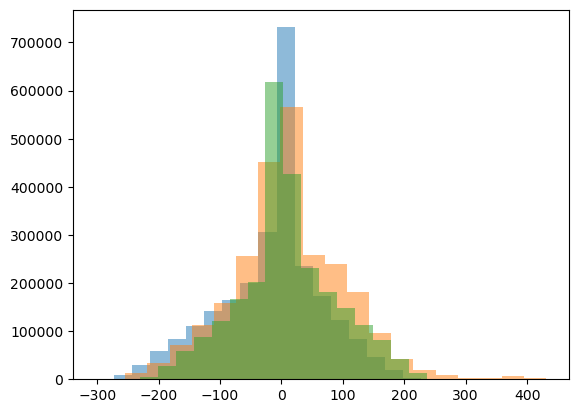

In [11]:
for id in ids:
    #load gas data
    ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
    comx2, comy2, comz2 = COMdefine(ppx2, ppy2, ppz2, ppm2)
    comx2, comy2, comz2 = [7702.1626,  7901.6797, 12109.929]
    print(comx2, comy2, comz2)
    plt.figure()
    plt.hist(ppx2-comx2, bins=20, alpha=0.5)
    plt.hist(ppy2-comy2, bins=20, alpha=0.5)
    plt.hist(ppz2-comz2, bins=20, alpha=0.5)
    assert False
    
    # plot
    plt.figure(figsize=(6,6))
    plt.subplot(111)
    plt.scatter(ppx2-comx2, ppy2-comy2, c=ppsfr2, marker='.', s=2,norm=colors.LogNorm(vmin=1e-5, vmax=np.max(ppsfr2)), cmap='viridis_r')
    
    plt.plot(comx2, comy2, 'kx',ms=8)
    # plt.axvline(x=0, ls='--', color='gray')
    plt.colorbar(label=r'SFR [M$_{\odot}$/yr]')
    plt.xlim(-75,75)
    plt.ylim(-75,75)
    # plt.xlim(7636, 7736)
    # plt.ylim(7862, 7962)
    plt.title('%s (gas)'%id)
    plt.xlabel('X [kpc]')
    plt.ylabel('Y [kpc]')


/var/folders/jv/4rv1kq017q5c_cp86hh8zxzc0000gp/T/ipykernel_62674/4209113447.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(ppx, ppy, c=ppgz, marker='.', s=1,vmin=np.min(ppgz), vmax=np.max(ppgz), cmap=plt.cm.get_cmap('viridis_r', 8),alpha=0.5)


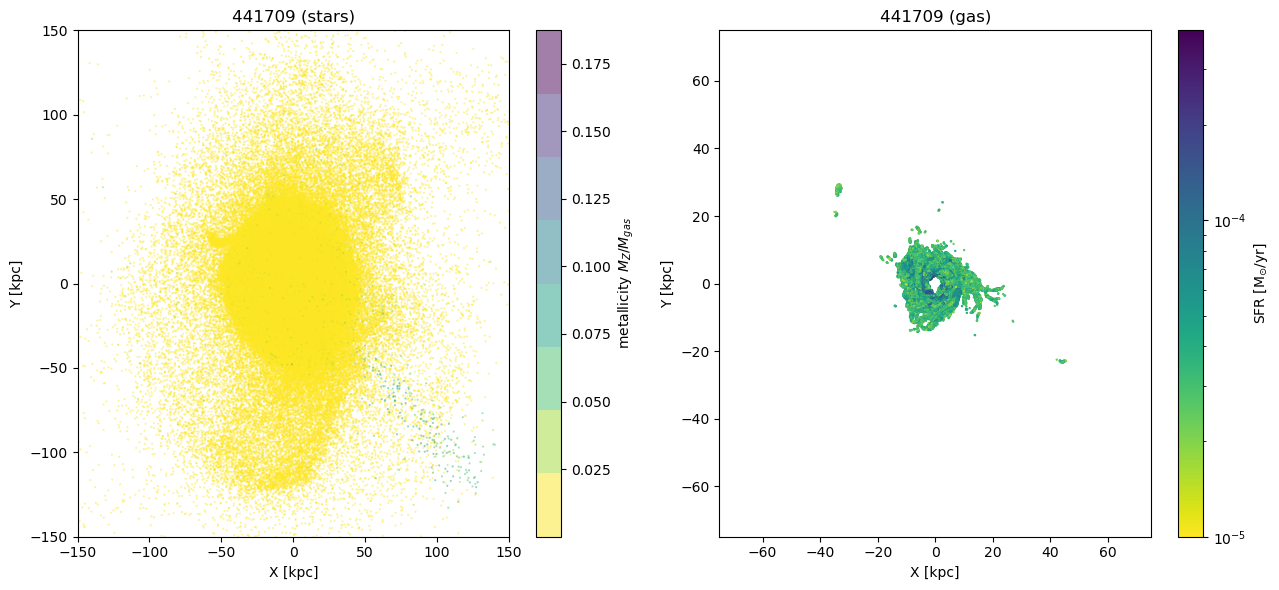

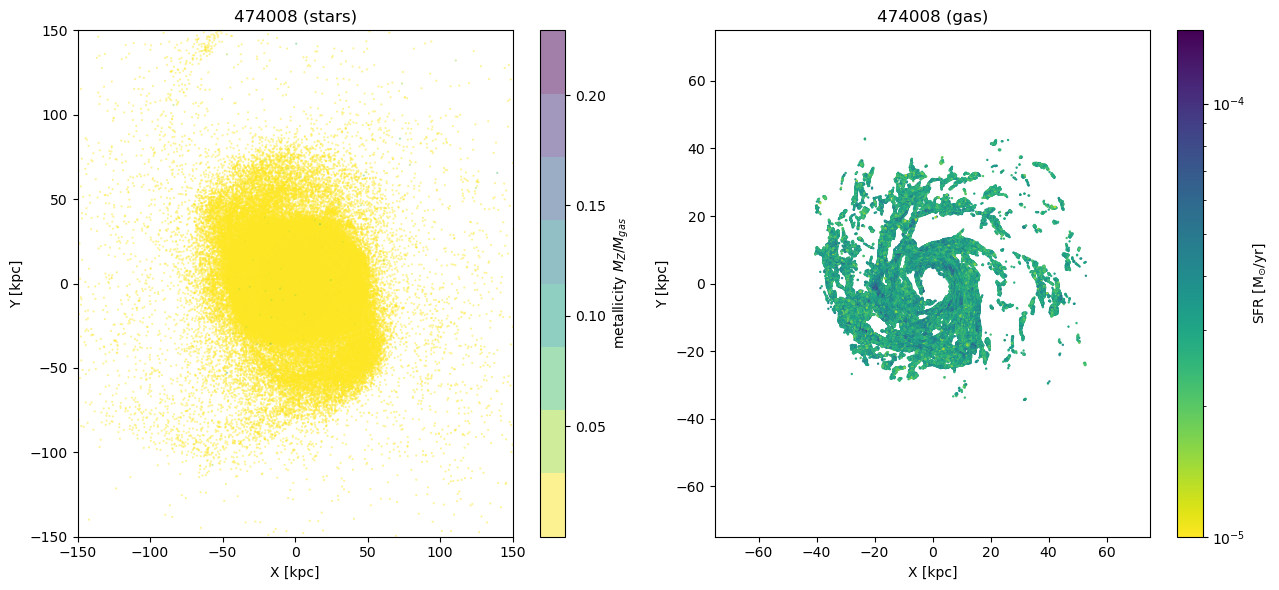

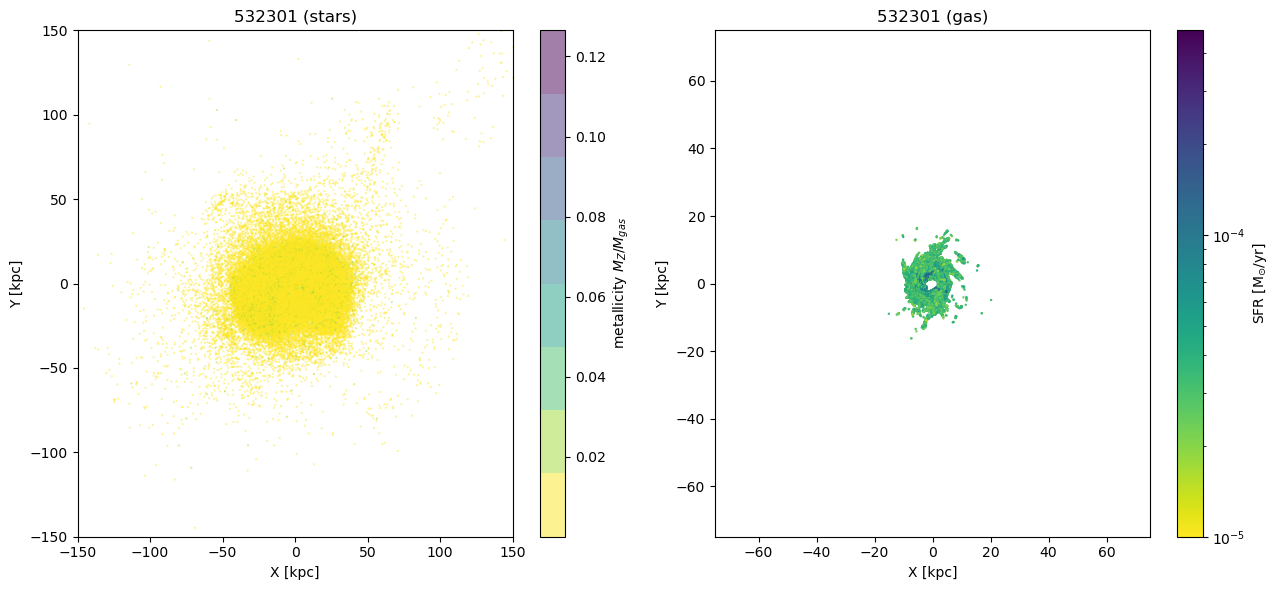

In [23]:
for id in ids:
    #load stellar data
    ppx, ppy, ppz, ppvx, ppvy, ppvz, ppm, ppage, ppgz = np.loadtxt('./%s_star_properties_TNGv2_rotated.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6, 7,8), unpack = True)
    #print len(ppz)
    #print len(ppgz), len(ppage[ppage >0.])
    
    ppx = ppx[ppage > 0.]
    ppy = ppy[ppage > 0.]
    ppz = ppz[ppage > 0.]
    ppm = ppm[ppage > 0.]
    ppgz = np.abs(ppgz[ppage > 0.])
    ppage = ppage[ppage > 0.]
    
    #load gas data
    ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
    #print np.min(ppsfr2), np.max(ppsfr2)
    
    # #load orbit data
    # orbit = np.loadtxt('M31analogs_major_merger_orbit_%s.txt'%id)
    
    # mask = np.where(orbit[:,0] == 103)[0][0] #snap 110 = 3.96 lookback Gyr, 103= 5.08 Gyr
    # xs = orbit[:,1][:mask+1]
    # ys = orbit[:,2][:mask+1]
    
    # xs = orbit[:,1]
    # ys = orbit[:,2]
    # plt.figure()
    # plt.hist(ppgz, bins=20)
    
    # plot
    plt.figure(figsize=(13,6))
    plt.subplot(121)
    plt.scatter(ppx, ppy, c=ppgz, marker='.', s=1,vmin=np.min(ppgz), vmax=np.max(ppgz), cmap=plt.cm.get_cmap('viridis_r', 8),alpha=0.5)
    # plt.plot(0., 0., 'kx',ms=8)
    # plt.plot(xs ,ys ,'k--')
    # plt.plot(xs[0], ys[0], 'ko')
    # m,b = per_bi(xs[0], ys[0], 0., 0.)
    # yrange = m*ppx+b
    # plt.plot(ppx, yrange, '--', c='gray')
    plt.colorbar(label=r'metallicity $M_Z/M_{gas}$')
    plt.xlim(-150,150)
    plt.ylim(-150,150)
    plt.title('%s (stars)'%id)
    plt.xlabel('X [kpc]')
    plt.ylabel('Y [kpc]')
    
    plt.subplot(122)
    plt.scatter(ppx2, ppy2, c=ppsfr2, marker='.', s=2,norm=colors.LogNorm(vmin=1e-5, vmax=np.max(ppsfr2)), cmap='viridis_r')
    # plt.plot(0., 0., 'kx', ms=8)
    # plt.plot(xs , ys ,'k--')
    # plt.plot(xs[0], ys[0], 'ko')
    # yrange2 = m*ppx2+b
    # plt.plot(ppx2, yrange2, '--', c='gray')
    plt.colorbar(label=r'SFR [M$_{\odot}$/yr]')
    plt.xlim(-75,75)
    plt.ylim(-75,75)
    plt.title('%s (gas)'%id)
    plt.xlabel('X [kpc]')
    plt.ylabel('Y [kpc]')
    plt.tight_layout()
    #plt.figtext(0.6, 0.85, 'merger time: %s Gyr' %round(time(snapnum2z(orbit[:,0][0]+1)),2))


## get last location of the progenitor and cut in half

In [ ]:
# for 532301, this is the location of the last time the merger was identified in snapshot 79
# SubfindID 444891 at Snap 79 (z = 0.2734):
#   Merger pos:    (19343.33, 20763.84, 578.61) kpc/h
#   Root pos:      (19344.43, 20762.50, 581.47) kpc/h
#   Separation:    4.25 ckpc/h  →  3.34 physical kpc/h
#snap 99 halo pos
#24615.44   26168.166    898.0169


# for ID 474008 at snap 99
# SubfindID 472021 at Snap 98 (z = 0.0095):
#   Merger pos:    (17658.66, 4328.85, 8068.40) kpc/h
#   Root pos:      (17686.10, 4344.64, 8067.33) kpc/h
#   Separation:    31.98 ckpc/h  →  31.68 physical kpc/h

# # for ID 441709
# SubfindID 433778 at Snap 97 (z = 0.0240):
#   Merger pos:    (7535.40, 7699.55, 11839.07) kpc/h
#   Root pos:      (7530.43, 7706.48, 11839.07) kpc/h
#   Separation:    8.74 ckpc/h  →  8.53 physical kpc/h

In [3]:
def per_bi(x1, y1, x2, y2):
    '''return the slope and intercept of the perpendicular bisector that passes through the center of the analog
    Inputs: x1, y1 are the location of the secondary
            x2, y2 are the location of the center '''
    mid = ((x1+x2)/2., (y1+y2)/2.)
    #print mid
    slope = (y2-y1)/(x2-x1)
    #print slope
    m = (1./slope)*-1.
    #b = mid[1] - (mid[0]*m)
    b = y2 - (x2*m)
    return m,b

In [4]:
m,b = per_bi(19343.33-19344.43, 20763.84-20762.50,0. ,0.)

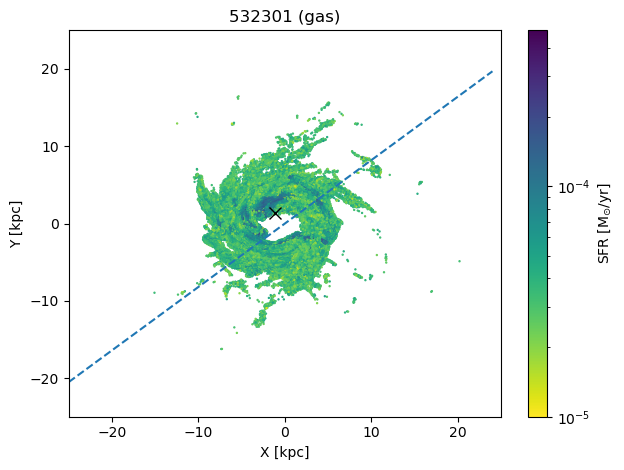

In [5]:
id = ids[2]

#load gas data
ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
#print np.min(ppsfr2), np.max(ppsfr2)

plt.scatter(ppx2, ppy2, c=ppsfr2, marker='.', s=2,norm=colors.LogNorm(vmin=1e-5, vmax=np.max(ppsfr2)), cmap='viridis_r')
plt.plot(19343.33-19344.43,20763.84-20762.50, 'kx', ms=8)
# plt.plot(xs , ys ,'k--')
# plt.plot(xs[0], ys[0], 'ko')
# yrange2 = m*ppx2+b
# plt.plot(ppx2, yrange2, '--', c='gray')
plt.colorbar(label=r'SFR [M$_{\odot}$/yr]')
plt.xlim(-25,25)
plt.ylim(-25,25)

plt.plot(np.arange(-25,25,1),np.arange(-25,25,1)*m+b, ls='--')
yy3 = ppx2*m+b
plt.title('%s (gas)'%id)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
plt.tight_layout()

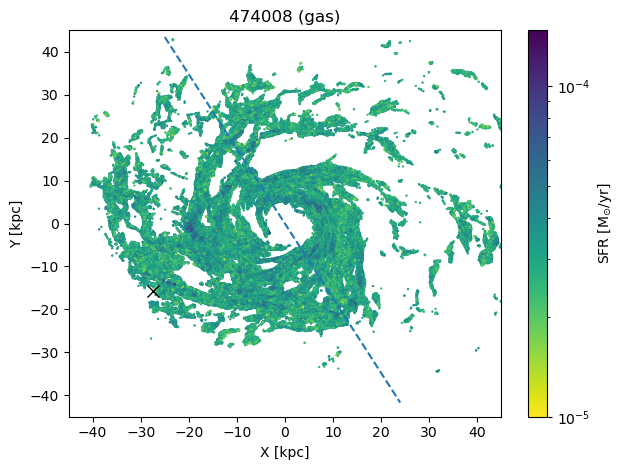

In [6]:
id = ids[1]

m,b = per_bi(17658.66-17686.10, 4328.85-4344.64,0. ,0.)

#load gas data
ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
#print np.min(ppsfr2), np.max(ppsfr2)

plt.scatter(ppx2, ppy2, c=ppsfr2, marker='.', s=2,norm=colors.LogNorm(vmin=1e-5, vmax=np.max(ppsfr2)), cmap='viridis_r')
plt.plot(17658.66-17686.10, 4328.85-4344.64, 'kx', ms=8)
# plt.plot(xs , ys ,'k--')
# plt.plot(xs[0], ys[0], 'ko')
# yrange2 = m*ppx2+b
# plt.plot(ppx2, yrange2, '--', c='gray')
plt.colorbar(label=r'SFR [M$_{\odot}$/yr]')
plt.xlim(-45,45)
plt.ylim(-45,45)

plt.plot(np.arange(-25,25,1),np.arange(-25,25,1)*m+b, ls='--')
yy2 = ppx2*m+b
plt.title('%s (gas)'%id)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
plt.tight_layout()

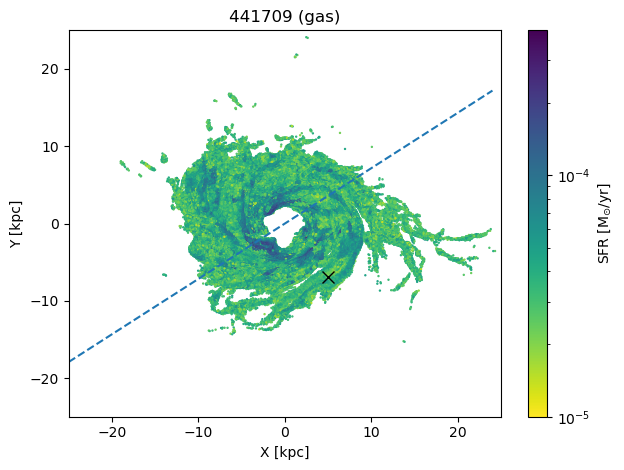

In [7]:
id = ids[0]


m,b = per_bi(7535.40-7530.43, 7699.55-7706.484,0. ,0.)

#load gas data
ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
#print np.min(ppsfr2), np.max(ppsfr2)

plt.scatter(ppx2, ppy2, c=ppsfr2, marker='.', s=2,norm=colors.LogNorm(vmin=1e-5, vmax=np.max(ppsfr2)), cmap='viridis_r')
plt.plot(7535.40-7530.43, 7699.55-7706.484, 'kx', ms=8)
# plt.plot(xs , ys ,'k--')
# plt.plot(xs[0], ys[0], 'ko')
# yrange2 = m*ppx2+b
# plt.plot(ppx2, yrange2, '--', c='gray')
plt.colorbar(label=r'SFR [M$_{\odot}$/yr]')
plt.xlim(-25,25)
plt.ylim(-25,25)

plt.plot(np.arange(-25,25,1),np.arange(-25,25,1)*m+b, ls='--')
yy1 = ppx2*m+b
plt.title('%s (gas)'%id)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
plt.tight_layout()

# find and save gas particle data for all snapshots preceding the merger to now

In [8]:
# right2 = (ppy2 <= yy)
# left2 = (ppy2 > yy)

# print('halves', len(ppsfr2[left2]), len(ppsfr2[right2]))
# print(np.sum(ppsfr2[left2]), np.sum(ppsfr2[right2]))

ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%ids[0], usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
right2 = (ppy2 <= yy1)
left2 = (ppy2 > yy1)
print(np.sum(ppsfr2[left2]), np.sum(ppsfr2[right2]))
norem1, rem1  = np.sum(ppsfr2[left2]), np.sum(ppsfr2[right2])

ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%ids[1], usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
right2 = (ppy2 <= yy2)
left2 = (ppy2 > yy2)
print(np.sum(ppsfr2[left2]), np.sum(ppsfr2[right2]))
norem2, rem2 = np.sum(ppsfr2[left2]), np.sum(ppsfr2[right2])

ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%ids[2], usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
right2 = (ppy2 <= yy3)
left2 = (ppy2 > yy3)
print(np.sum(ppsfr2[left2]), np.sum(ppsfr2[right2]))
rem3, norem3  = np.sum(ppsfr2[left2]), np.sum(ppsfr2[right2])


10.167457961216314 9.842098793804325
3.2620674683494144 5.720545816662707
4.99102899801801 3.5036515150914056


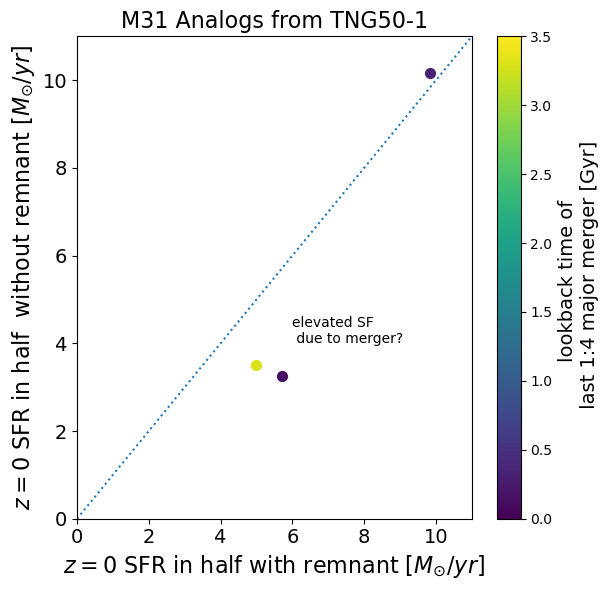

In [45]:
plt.figure(figsize=(6.2,6))
#right, left, left
plt.scatter(rem1, norem1, c=0.34,vmin=0, vmax=3.5,s=50)
plt.scatter(rem2, norem2, c=0.14,vmin=0, vmax=3.5,s=50)
plt.scatter(rem3, norem3, c=3.3,vmin=0, vmax=3.5,s=50)
plt.xlim(0,11)
plt.ylim(0,11)
plt.plot(np.arange(0,12,1), np.arange(0,12,1), ls=':')
cbar = plt.colorbar()
cbar.set_label(label='lookback time of \n last 1:4 major merger [Gyr]',size=14)
plt.xlabel(r'$z=0$ SFR in half with remnant [$M_{\odot}/yr$]', fontsize=16)
plt.ylabel(r'$z=0$ SFR in half  without remnant [$M_{\odot}/yr$]', fontsize=16)
plt.title('M31 Analogs from TNG50-1', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.text(6,4, 'elevated SF\n due to merger?')
plt.tight_layout()
plt.savefig('TNG50_SFR_comp.png')